In [ ]:
"""
Data Understanding and Exploratory Data Analysis (EDA)
E-Commerce Return Fraud Detection Dataset

This notebook performs comprehensive data exploration and quality assessment
to understand the structure, patterns, and data quality issues.
"""

# Standard library imports
import os
import sys
from pathlib import Path

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure plotting defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# E-Commerce Return Fraud Detection - Data Understanding

## Objective
Perform comprehensive exploratory data analysis (EDA) on the e-commerce return fraud dataset to:
- Understand data structure and characteristics
- Identify data quality issues
- Detect anomalies and outliers
- Inform data cleaning and preprocessing strategies

In [2]:
df = pd.read_csv(r'data/raw/ecommerce_return_fraud_dataset.csv')

In [3]:
df.head()

,order_id,customer_id,customer_age,gender,city_tier,membership_type,account_age_days,total_orders,previous_returns,return_rate,...,device_type,ip_risk_score,order_date,delivery_date,return_request_date,refund_processed_date,fraud_investigation_status,refund_approved,final_fraud_decision,return_fraud
0,ORD0000000,CUST000000,56.0,Male,Tier2,GOLD,2680,163,32,0.196319,...,Android,8,2024-07-29,2024-12-16,2024-11-06,2026-02-08,Investigating,Yes,Fraud,1
1,ORD0000001,CUST000001,69.0,Male,Tier2,GOLD,252,117,24,0.205128,...,iPhone,42,2025-07-15,2026-02-25,2024-10-03,2025-05-27,Fraud Confirmed,No,Fraud,1
2,ORD0000002,CUST000002,NaN,Male,Tier2,Gold,1482,96,49,0.510417,...,iPhone,27,2023-09-06,2025-01-07,2025-11-07,2024-11-14,Investigating,Yes,Fraud,1
3,ORD0000003,CUST000003,NaN,Male,Tier1,Platinum,2470,151,41,0.271523,...,iPhone,77,2026-02-15,2025-03-04,2025-03-12,2026-05-25,Genuine,Yes,Fraud,1
4,ORD0000004,CUST000004,60.0,M,Tier1,Platinum,816,84,41,0.488095,...,iPhone,11,2026-01-17,2026-04-10,2026-05-08,2024-12-04,Investigating,Yes,Fraud,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    50500 non-null  str    
 1   customer_id                 50500 non-null  str    
 2   customer_age                42971 non-null  float64
 3   gender                      50500 non-null  str    
 4   city_tier                   50500 non-null  str    
 5   membership_type             43750 non-null  str    
 6   account_age_days            50500 non-null  int64  
 7   total_orders                50500 non-null  int64  
 8   previous_returns            50500 non-null  int64  
 9   return_rate                 50500 non-null  float64
 10  product_category            50500 non-null  str    
 11  product_price               43984 non-null  str    
 12  discount_percent            50500 non-null  str    
 13  order_amount                50500 non-null

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,42971.0,43.718880,16.944463,-10.000000,31.000000,43.000000,56.00000,200.000000
account_age_days,50500.0,2017.212356,1144.421084,30.000000,1025.000000,2015.000000,3005.00000,3999.000000
total_orders,50500.0,105.039644,165.831319,1.000000,51.000000,101.000000,150.00000,5000.000000
previous_returns,50500.0,26.408376,63.792706,0.000000,12.000000,24.000000,37.00000,2000.000000
return_rate,50500.0,0.697114,2.299785,0.000000,0.119197,0.243902,0.48750,49.000000
order_amount,50500.0,32641.962979,21965.106632,162.084289,14823.266783,29134.874711,47029.69878,99800.589737
delivery_days,50500.0,7.484693,4.037776,1.000000,4.000000,7.000000,11.00000,14.000000
days_to_return,50500.0,15.015149,8.347881,1.000000,8.000000,15.000000,22.00000,29.000000
customer_rating,42925.0,2.995737,1.412056,1.000000,2.000000,3.000000,4.00000,5.000000
customer_support_tickets,50500.0,9.491881,5.766116,0.000000,4.000000,9.000000,15.00000,19.000000


Target variable analysis

In [12]:

fraud_counts = df['return_fraud'].value_counts()
print(fraud_counts)
print()
print("Percentage Split:")
print(df['return_fraud'].value_counts(normalize=True) * 100)

return_fraud
1    35487
0    15013
Name: count, dtype: int64

Percentage Split:
return_fraud
1    70.271287
0    29.728713
Name: proportion, dtype: float64


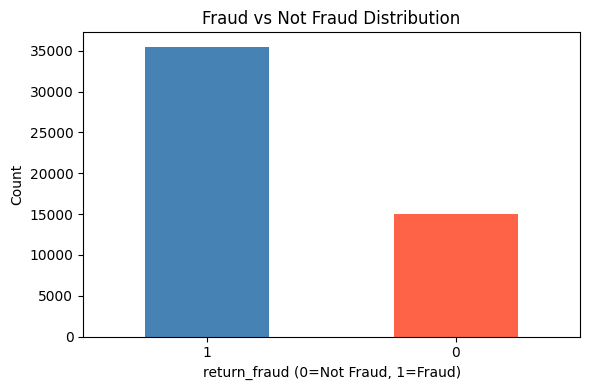

In [16]:

plt.figure(figsize=(6, 4))
df['return_fraud'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Fraud vs Not Fraud Distribution')
plt.xlabel('return_fraud (0=Not Fraud, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r'D:\projects\commerce dataset\E-commerce\New folder\target_distribution.png')
plt.show()

Identifying dirty categorical values

In [17]:

cols_to_check = ['gender', 'membership_type', 'city_tier', 
                 'product_category', 'payment_method', 
                 'return_reason', 'device_type',
                 'fraud_investigation_status', 'refund_approved', 
                 'final_fraud_decision']

print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
for col in cols_to_check:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())

UNIQUE VALUES IN CATEGORICAL COLUMNS

gender (5 unique values):
<ArrowStringArray>
['Male', 'M', 'Female', 'MALE', 'male']
Length: 5, dtype: str

membership_type (6 unique values):
<ArrowStringArray>
['GOLD', 'Gold', 'Platinum', nan, 'Silver', 'gold', 'Gld']
Length: 7, dtype: str

city_tier (3 unique values):
<ArrowStringArray>
['Tier2', 'Tier1', 'Tier3']
Length: 3, dtype: str

product_category (6 unique values):
<ArrowStringArray>
['Furniture', 'Electronics', 'Appliances', 'Fashion', 'Mobile', 'Books']
Length: 6, dtype: str

payment_method (5 unique values):
<ArrowStringArray>
['COD', 'Net Banking', 'Credit Card', 'Debit Card', 'UPI']
Length: 5, dtype: str

return_reason (5 unique values):
<ArrowStringArray>
['Quality Issue', 'Wrong Item', 'Not Needed', 'Size Issue', 'Damaged']
Length: 5, dtype: str

device_type (4 unique values):
<ArrowStringArray>
['Android', 'iPhone', 'Tablet', 'Desktop']
Length: 4, dtype: str

fraud_investigation_status (3 unique values):
<ArrowStringArray>
['Inve

Missing values quick check

In [20]:
print("MISSING VALUES COUNT")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False
)

print(missing_df)

MISSING VALUES COUNT
                 Missing Count  Missing Percentage
customer_rating           7575           15.000000
customer_age              7529           14.908911
membership_type           6750           13.366337
product_price             6516           12.902970


In [26]:
# Project documentation 
summary = """
DATA UNDERSTANDING SUMMARY

Dataset: E-Commerce Return Fraud Detection
Total Records: {}
Total Features: {}
Target Variable: return_fraud (Binary: 0=Not Fraud, 1=Fraud)

FRAUD DISTRIBUTION:
{}

KEY OBSERVATIONS:
1. product_price has ₹ symbol — needs cleaning (object -> float)
2. discount_percent has % symbol — needs cleaning (object -> float)  
3. gender column has inconsistent values (Male/M/male/MALE)
4. membership_type has inconsistent values (Gold/GOLD/gold/Gld)
5. Date columns have multiple formats — needs standardization
6. customer_age, customer_rating have missing values
7. return_rate > 1 in some rows — mathematically impossible (outlier)
8. product_price = 99999999 in one row — likely data entry error

LEAKAGE SUSPECTS (to be confirmed):
- fraud_investigation_status
- refund_approved  
- final_fraud_decision
""".format(
    df.shape[0],
    df.shape[1],
    df['return_fraud'].value_counts()
)

print(summary)

# Saving summary to reports folder
with open(r'D:\projects\commerce dataset\E-commerce\reports\data_understanding_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("Summary saved to reports folder")






DATA UNDERSTANDING SUMMARY

Dataset: E-Commerce Return Fraud Detection
Total Records: 50500
Total Features: 30
Target Variable: return_fraud (Binary: 0=Not Fraud, 1=Fraud)

FRAUD DISTRIBUTION:
return_fraud
1    35487
0    15013
Name: count, dtype: int64

KEY OBSERVATIONS:
1. product_price has ₹ symbol — needs cleaning (object -> float)
2. discount_percent has % symbol — needs cleaning (object -> float)  
3. gender column has inconsistent values (Male/M/male/MALE)
4. membership_type has inconsistent values (Gold/GOLD/gold/Gld)
5. Date columns have multiple formats — needs standardization
6. customer_age, customer_rating have missing values
7. return_rate > 1 in some rows — mathematically impossible (outlier)
8. product_price = 99999999 in one row — likely data entry error

LEAKAGE SUSPECTS (to be confirmed):
- fraud_investigation_status
- refund_approved  
- final_fraud_decision

Summary saved to reports folder
